# Mean Baseline Notebook

This notebook computes the mean-height baseline metrics for the cleaned dataset and reports the average height across the combined train, validation, and test splits.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_from_disk
from tqdm import tqdm


def resolve_cleaned_data_path() -> Path:
    candidates = [Path.cwd() / "cleaned_data", Path.cwd().parent / "cleaned_data"]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find a cleaned_data directory from the notebook location.")


def apply_minimal_transforms(examples):
    return {
        "target_height": [torch.tensor(float(h), dtype=torch.float32) for h in examples["height"]]
    }


Using device: cpu
Loading cleaned data from: /Users/azalearohr/Documents/GitHub/DS593_Final_Project/cleaned_data


Mean height from training set: 171.49
Number of training samples: 5442
Average height from all cleaned data: 171.42
Minimum height in all cleaned data: 79.25
Maximum height in all cleaned data: 259.08
Number of validation samples: 605
Number of test samples: 673
Number of cleaned samples total: 6720


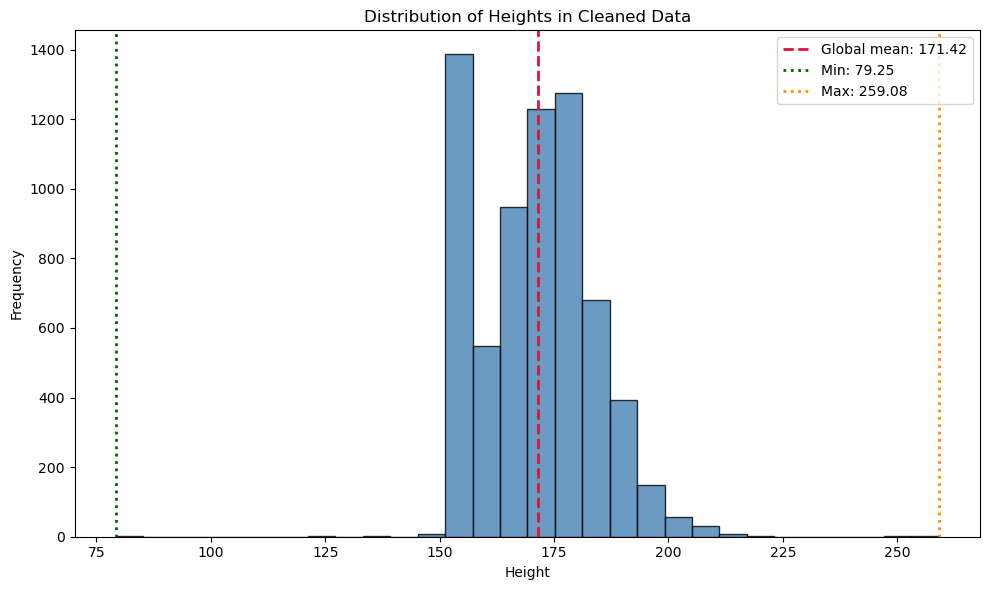

Evaluating train set: 100%|██████████| 341/341 [00:33<00:00, 10.03it/s]


Train MSE: 150.69


Evaluating validation set: 100%|██████████| 38/38 [00:03<00:00, 11.78it/s]


Validation MSE: 164.16


Evaluating test set: 100%|██████████| 43/43 [00:04<00:00,  9.46it/s]

Test MSE: 141.11
Global MSE (all cleaned data combined): 150.94
Number of global samples: 6720


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset_path = resolve_cleaned_data_path()
print(f"Loading cleaned data from: {dataset_path}")

dataset = load_from_disk(str(dataset_path))
dataset = dataset.with_transform(apply_minimal_transforms)

train_heights = [example["target_height"].item() for example in tqdm(dataset["train"], desc="Collecting train heights")]
val_heights = [example["target_height"].item() for example in tqdm(dataset["validation"], desc="Collecting validation heights")]
test_heights = [example["target_height"].item() for example in tqdm(dataset["test"], desc="Collecting test heights")]

mean_height = sum(train_heights) / len(train_heights)
all_heights = train_heights + val_heights + test_heights
global_mean_height = sum(all_heights) / len(all_heights)
min_height = min(all_heights)
max_height = max(all_heights)

print(f"Mean height from training set: {mean_height:.2f}")
print(f"Number of training samples: {len(train_heights)}")
print(f"Average height from all cleaned data: {global_mean_height:.2f}")
print(f"Minimum height in all cleaned data: {min_height:.2f}")
print(f"Maximum height in all cleaned data: {max_height:.2f}")
print(f"Number of validation samples: {len(val_heights)}")
print(f"Number of test samples: {len(test_heights)}")
print(f"Number of cleaned samples total: {len(all_heights)}")

plt.figure(figsize=(10, 6))
plt.hist(all_heights, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
plt.axvline(global_mean_height, color="crimson", linestyle="--", linewidth=2, label=f"Global mean: {global_mean_height:.2f}")
plt.axvline(min_height, color="darkgreen", linestyle=":", linewidth=2, label=f"Min: {min_height:.2f}")
plt.axvline(max_height, color="darkorange", linestyle=":", linewidth=2, label=f"Max: {max_height:.2f}")
plt.title("Distribution of Heights in Cleaned Data")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

criterion = nn.MSELoss()


def evaluate_mean(split_name, baseline_value, batch_size=16):
    loader = DataLoader(dataset[split_name], batch_size=batch_size)
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {split_name} set"):
            targets = batch["target_height"].to(device)
            predictions = torch.full_like(targets, baseline_value)
            loss = criterion(predictions, targets)
            total_loss += loss.item() * targets.size(0)
            total_samples += targets.size(0)

    mse = total_loss / total_samples
    return mse, total_samples


def compute_mse_from_heights(heights, baseline_value):
    squared_errors = [(height - baseline_value) ** 2 for height in heights]
    return sum(squared_errors) / len(squared_errors)


train_mse, train_samples = evaluate_mean("train", mean_height)
print(f"Train MSE: {train_mse:.2f}")

val_mse, val_samples = evaluate_mean("validation", mean_height)
print(f"Validation MSE: {val_mse:.2f}")

test_mse, test_samples = evaluate_mean("test", mean_height)
print(f"Test MSE: {test_mse:.2f}")

global_mse = compute_mse_from_heights(all_heights, global_mean_height)
print(f"Global MSE (all cleaned data combined): {global_mse:.2f}")
print(f"Number of global samples: {len(all_heights)}")
